In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.
Path to dataset files: /kaggle/input/red-wine-quality-cortez-et-al-2009


In [3]:
import pandas as pd

# Path from kagglehub
path = "/kaggle/input/red-wine-quality-cortez-et-al-2009/winequality-red.csv"

# Load dataset
df = pd.read_csv(path)
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [4]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


<Axes: >

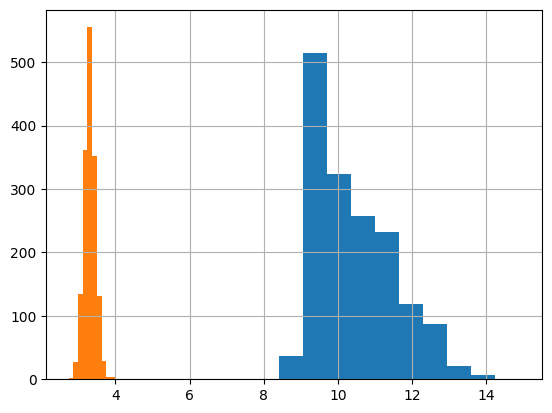

In [5]:
#eda
#histogram for numeric data
df['alcohol'].hist()
df['pH'].hist()


In [6]:
df['quality'].value_counts().sort_index()
#class imbalance


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


<Axes: xlabel='quality', ylabel='alcohol'>

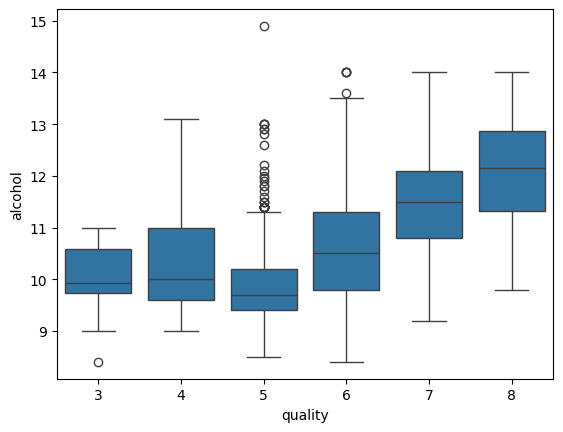

In [7]:
import seaborn as sns
sns.boxplot(x='quality', y='alcohol', data=df)


<Axes: xlabel='volatile acidity', ylabel='quality'>

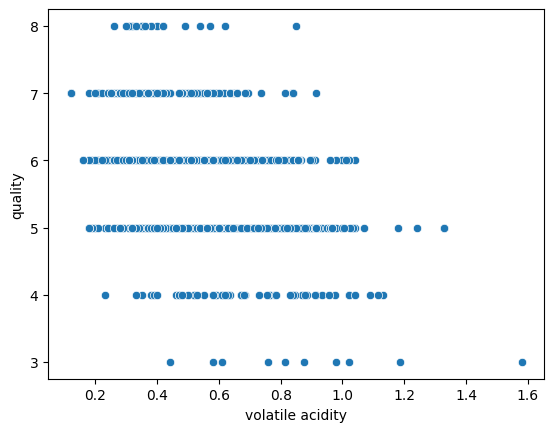

In [8]:
sns.scatterplot(x='volatile acidity', y='quality', data=df)


<Axes: >

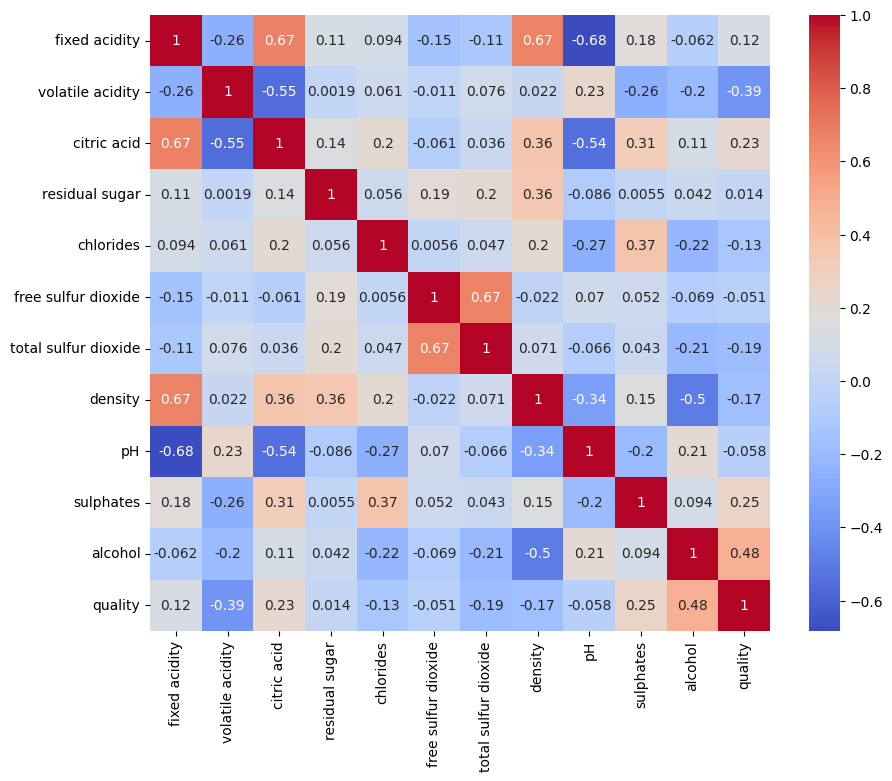

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")


In [10]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


In [17]:
# Define X (features) and y (target)
X = df.drop("quality", axis=1)   # all columns except 'quality'
y = df["quality"]                # the target column

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.preprocessing import LinearRegression
